In [2]:
from dynrdpg import DynamicRDPG
from dynrdpg.datasets import simulate_network_rw, simulate_network_gp

0.09890400000000002


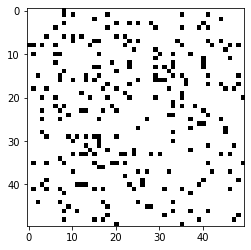

In [37]:
Y, X = simulate_network_gp(
    n_nodes=50, n_time_steps=100, density=0.1, random_state=5)

print(np.mean([Yt.mean() for Yt in Y]))

plt.imshow(Y[-1].toarray(), cmap='gray_r')

In [38]:
import os

out_dir = f'fase_data/'
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

np.savetxt(os.path.join(out_dir, 'time_points.npy'), np.linspace(0, 1, len(Y)))
for t in range(len(Y)):
    np.savetxt(os.path.join(out_dir, f'Y_{t+1}.npy'), Y[t].toarray())
    np.savetxt(os.path.join(out_dir, f'X_{t+1}.npy'), X[t])

In [39]:
! Rscript fase.R

Type 'citation("pROC")' for a citation.

Attaching package: ‘pROC’

The following objects are masked from ‘package:stats’:

    cov, smooth, var


── Column specification ────────────────────────────────────────────────────────
cols(
  X1 = col_double()
)

[1] "q = 4 ngcv = -1.22188275456877"
[1] "q = 6 ngcv = -1.22262509202426"
[1] "q = 8 ngcv = -1.22200058367677"
[1] "q = 10 ngcv = -1.22098989255531"
[1] "q = 12 ngcv = -1.22003410949105"
[1] "q = 14 ngcv = -1.21917088960845"
[1] "q = 16 ngcv = -1.21840310595007"
[1] 0.008626651


In [42]:
rdpg = DynamicRDPG(n_features=2, rw_order=1)
rdpg.sample(Y, n_burnin=200, n_samples=200)

/Users/joshua/.pyenv/versions/stats/lib/python3.10/site-packages/graspologic/embed/base.py:199: UserWarning: Input graph is not fully connected. Results may notbe optimal. You can compute the largest connected component byusing ``graspologic.utils.largest_connected_component``.
  warnings.warn(msg, UserWarning)
100%|███████████████████████████████████████████████████████████████████| 400/400 [00:50<00:00,  7.95it/s]


In [43]:
from scipy.linalg import orthogonal_procrustes

X_pred = rdpg.X_.copy()
for t in range(len(Y)):
    R, _ = orthogonal_procrustes(X_pred[t], X[t])
    X_pred[t] = X_pred[t] @ R
    
print(rdpg.auc_)
np.mean((X_pred - X) ** 2)

0.691055143632775


0.007593000568958887